# ST-GCN - matching Yan et al. 2018's actual configuration

mmaction2 as the framework (VideoBadminton's own stated tooling), but every architectural and training number pulled from the paper's text, not mmaction2's own modernized default config, which we'd been silently using until now.

**What's different from the earlier run:**
- 9 ST-GCN units, not 10 (`num_stages=9`)
- Channel/stride inflation at units 4 and 7, not the default 5 and 8
- Basic augmentation (rotate/scale/jitter/mirror/crop) instead of the advanced set
- **No backbone dropout** - the paper states augmentation replaces dropout specifically for unconstrained-camera datasets like Kinetics, which broadcast badminton resembles far more than NTU's fixed lab cameras
- SGD lr=0.01, decayed x0.1 every 10 epochs (the paper's literal schedule) - not ReduceLROnPlateau
- **No NTU60 pretrained init** - the modified 9-stage shapes won't match the checkpoint anyway, and the paper itself trains from scratch, so this is the more faithful choice, not a compromise

Where the paper doesn't state a value (momentum, weight_decay, total epochs), the assumption used is flagged in a comment at that line - not silently invented.

### determinism - before torch touches CUDA

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, top_k_accuracy_score, confusion_matrix

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(42)
np.random.seed(42)

sys.path.insert(0, "/workspace/badminton-honours-project")
import dataset as ds

import mmaction.models  # noqa: F401
from mmaction.utils import register_all_modules
register_all_modules()
from mmaction.registry import MODELS

from clearml import Task

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda:0


### paths

In [2]:
OUT_ROOT = "/workspace/outputs/stgcn_paper_faithful"
CKPT_ROOT = "/workspace/checkpoints/stgcn_paper_faithful"
os.makedirs(OUT_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)


### data - basic augmentation policy only, per this test's purpose

In [3]:
manifest = ds.load_filtered_manifest(
    "/workspace/data/split_manifest.csv",
    "/workspace/data/extraction_log.csv",
)

class_names = sorted(manifest["class_name"].unique())
class_to_id = {name: i for i, name in enumerate(class_names)}
num_classes = len(class_names)

train_manifest = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_manifest = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_manifest = manifest[manifest["split"] == "test"].reset_index(drop=True)

KEYPOINTS_ROOT = "/workspace/data/keypoints_smoothed"

train_ds = ds.BadmintonPoseDataset(train_manifest, KEYPOINTS_ROOT, class_to_id, augmentation_policy="basic")
val_ds = ds.BadmintonPoseDataset(val_manifest, KEYPOINTS_ROOT, class_to_id)
test_ds = ds.BadmintonPoseDataset(test_manifest, KEYPOINTS_ROOT, class_to_id)

balanced_sampler = ds.build_class_balanced_sampler(train_manifest, target_per_class=500, seed=42)

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"{num_classes} classes, train {len(train_manifest)}, val {len(val_ds)}, test {len(test_ds)}")


dropped 4 manually-excluded clips from the manifest (7814 remain)
18 classes, train 6251, val 781, test 782


### batch -> ST-GCN input

same shape-corrected function verified earlier: (N, num_clips=1, M=1, T, V, C), channels last

In [4]:
def batch_to_stgcn_input(batch):
    kp = batch["keypoints"].float()   # (N, T, V, 3) - x, y, confidence only
    x = kp.unsqueeze(1).unsqueeze(1)   # (N, num_clips=1, M=1, T, V, C)
    return x


### the paper-faithful model config

9 stages, inflate/down at [4, 7] (not mmaction2's default [5, 8]), no tcn_dropout (augmentation is doing that job instead, per the paper's own stated design for unconstrained-camera footage).

In [5]:
model_cfg = dict(
    type="RecognizerGCN",
    backbone=dict(
        type="STGCN",
        graph_cfg=dict(layout="coco", mode="stgcn_spatial"),
        in_channels=3,
        base_channels=64,      # paper: "first three layers have 64 channels"
        ch_ratio=2,            # channels double at each inflation point (64->128->256)
        num_stages=9,          # paper: "composed of 9 layers of spatial temporal graph convolution operators"
        inflate_stages=[4, 7], # paper: channels change after unit 3 and unit 6, i.e. inflating INTO units 4 and 7
        down_stages=[4, 7],    # paper: "strides of the 4-th and the 7-th temporal convolution layers are set to 2"
        # tcn_dropout intentionally left at its default (0) - not set here. The paper states
        # augmentation REPLACES dropout when training on unconstrained-camera data like Kinetics,
        # which broadcast badminton resembles far more than NTU-RGB+D's fixed lab cameras.
    ),
    cls_head=dict(
        type="GCNHead",
        num_classes=num_classes,
        in_channels=256,       # paper: "last three layers have 256 channels", global pooled to this size
        loss_cls=dict(type="CrossEntropyLoss"),
    ),
)

model = MODELS.build(model_cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model built, {n_params:,} parameters")


model built, 3,027,379 parameters


### SMOKE TEST - run this cell alone first

Same shape contract as before, but worth re-confirming since the backbone's internal structure changed (9 stages instead of 10). If this fails, stop and check the traceback before running anything below - don't assume the earlier verification still applies unchanged to a modified architecture.

In [6]:
smoke_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
smoke_batch = next(iter(smoke_loader))
smoke_input = batch_to_stgcn_input(smoke_batch).to(device)
print("input shape:", smoke_input.shape)

model.eval()
with torch.no_grad():
    smoke_output = model(smoke_input, mode="tensor", stage="head")

print("output shape:", smoke_output.shape)
assert smoke_output.shape == (4, num_classes), f"expected (4, {num_classes}), got {smoke_output.shape}"
print("smoke test passed")


input shape: torch.Size([4, 1, 1, 30, 17, 3])
output shape: torch.Size([4, 18])
smoke test passed


### metrics - identical definitions used throughout this project

In [7]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for batch in loader:
        x = batch_to_stgcn_input(batch).to(device)
        y = batch["label"].to(device)
        logits = model(x, mode="tensor", stage="head")
        probs = torch.softmax(logits, dim=1)

        all_labels.append(y.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)

    top1 = accuracy_score(labels, preds)
    top5 = top_k_accuracy_score(labels, probs, k=5, labels=list(range(num_classes)))
    mca = balanced_accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")

    return {"top1": top1, "top5": top5, "mca": mca, "macro_f1": macro_f1, "labels": labels, "preds": preds}


### training - the paper's literal schedule

SGD lr=0.01, decayed x0.1 every 10 epochs (StepLR, not ReduceLROnPlateau - matches the paper's exact stated schedule rather than an adaptive one). Momentum (0.9) and weight_decay (5e-4) aren't stated in the paper - both are flagged here as filled-in defaults, not paper-derived numbers. Total epoch count (60) is also our own choice, picked to allow 6 full decay cycles since the paper doesn't state a total.

In [8]:
NUM_EPOCHS = 60       # not stated in the paper - chosen to allow 6 decay cycles at step_size=10
PATIENCE = 20         # safety net in case it converges or overfits faster than the schedule assumes
BATCH_SIZE = 16
LR = 0.01             # paper-stated
MOMENTUM = 0.9        # NOT stated in the paper - standard-era default, flagged as an assumption
WEIGHT_DECAY = 5e-4   # NOT stated in the paper - matches mmaction2's own reference value

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=balanced_sampler, num_workers=4, pin_memory=True, persistent_workers=True)

task = Task.init(project_name="BadmintonPoseAnalysis", task_name="stgcn_paper_faithful_basic", reuse_last_task_id=False)
logger = task.get_logger()
task.connect({
    "lr": LR, "momentum": MOMENTUM, "weight_decay": WEIGHT_DECAY,
    "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE,
    "num_stages": 9, "inflate_stages": [4, 7], "down_stages": [4, 7],
    "tcn_dropout": "default (0) - augmentation used instead per paper",
    "augmentation_policy": "basic", "ntu60_pretrained": False,
})

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_mca": [], "lr": []}
best_val_top1 = 0.0
epochs_without_improvement = 0
best_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_labels, epoch_preds = [], []

    for batch in train_loader:
        x = batch_to_stgcn_input(batch).to(device)
        y = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(x, mode="tensor", stage="head")
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x.size(0)
        epoch_labels.append(y.cpu().numpy())
        epoch_preds.append(logits.argmax(dim=1).cpu().numpy())

    scheduler.step()

    train_loss = epoch_loss / len(train_loader.dataset)
    train_acc = accuracy_score(np.concatenate(epoch_labels), np.concatenate(epoch_preds))

    val_metrics = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_metrics["top1"])
    history["val_mca"].append(val_metrics["mca"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    logger.report_scalar("loss", "train", train_loss, iteration=epoch)
    logger.report_scalar("accuracy", "train", train_acc, iteration=epoch)
    logger.report_scalar("accuracy", "val_top1", val_metrics["top1"], iteration=epoch)
    logger.report_scalar("accuracy", "val_mca", val_metrics["mca"], iteration=epoch)
    logger.report_scalar("lr", "value", optimizer.param_groups[0]["lr"], iteration=epoch)

    if val_metrics["top1"] > best_val_top1:
        best_val_top1 = val_metrics["top1"]
        epochs_without_improvement = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    print(f"epoch {epoch:3d}  lr={optimizer.param_groups[0]['lr']:.5f}  train_loss={train_loss:.4f}  "
          f"train_acc={train_acc:.4f}  val_top1={val_metrics['top1']:.4f}  val_mca={val_metrics['mca']:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"early stopping at epoch {epoch}, best val_top1={best_val_top1:.4f}")
        break

model.load_state_dict(best_state)


ClearML Task: created new task id=3c81634b44aa421195bec4dd5b9bc00e
2026-09-10 04:04:59,028 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/3c81634b44aa421195bec4dd5b9bc00e/output/log
epoch   0  lr=0.01000  train_loss=3.6143  train_acc=0.2969  val_top1=0.5224  val_mca=0.3698
epoch   1  lr=0.01000  train_loss=2.8656  train_acc=0.4345  val_top1=0.5237  val_mca=0.4937
epoch   2  lr=0.01000  train_loss=2.4927  train_acc=0.5012  val_top1=0.5647  val_mca=0.5532
epoch   3  lr=0.01000  train_loss=2.2624  train_acc=0.5502  val_top1=0.6031  val_mca=0.5467
epoch   4  lr=0.01000  train_loss=2.0967  train_acc=0.5778  val_top1=0.5941  val_mca=0.5399
epoch   5  lr=0.01000  train_loss=1.9621  train_acc=0.6003  val_top1=0.6440  val_mca=0.5520
epoch   6  lr=0.01000  train_loss=1.8476  train_acc=0.6215  val_top1=0.6633  val_mca=0.5850
epoch   7  lr=0.01000  train_loss=1.7406  tr

<All keys matched successfully>

███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  8.18MB/s]: 


### final evaluation and comparison against the benchmark

In [9]:
LI_ET_AL_BENCHMARK = {"test_top1": 0.7441, "test_top5": 0.9376, "test_mca": 0.6144}

train_final = evaluate(model, DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True))
val_final = evaluate(model, val_loader)
test_final = evaluate(model, test_loader)

metrics = {
    "train_acc": train_final["top1"],
    "val_acc": val_final["top1"],
    "test_top1": test_final["top1"],
    "test_top5": test_final["top5"],
    "test_mca": test_final["mca"],
    "test_macro_f1": test_final["macro_f1"],
    "train_test_gap": train_final["top1"] - test_final["top1"],
}

ckpt_path = os.path.join(CKPT_ROOT, "stgcn_paper_faithful_basic_best.pt")
torch.save(model.state_dict(), ckpt_path)

with open(os.path.join(OUT_ROOT, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
with open(os.path.join(OUT_ROOT, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

task.upload_artifact("checkpoint", ckpt_path)
task.upload_artifact("metrics", metrics)
task.close()

print()
print(f"train_acc={metrics['train_acc']:.4f}  test_top1={metrics['test_top1']:.4f}  gap={metrics['train_test_gap']:.4f}")
print(f"test_top5={metrics['test_top5']:.4f}  test_mca={metrics['test_mca']:.4f}  test_macro_f1={metrics['test_macro_f1']:.4f}")
print(f"Li et al. benchmark: test_top1={LI_ET_AL_BENCHMARK['test_top1']:.4f}  test_top5={LI_ET_AL_BENCHMARK['test_top5']:.4f}  test_mca={LI_ET_AL_BENCHMARK['test_mca']:.4f}")



train_acc=0.9275  test_top1=0.6905  gap=0.2370
test_top5=0.9476  test_mca=0.5925  test_macro_f1=0.6052
Li et al. benchmark: test_top1=0.7441  test_top5=0.9376  test_mca=0.6144


### training curves

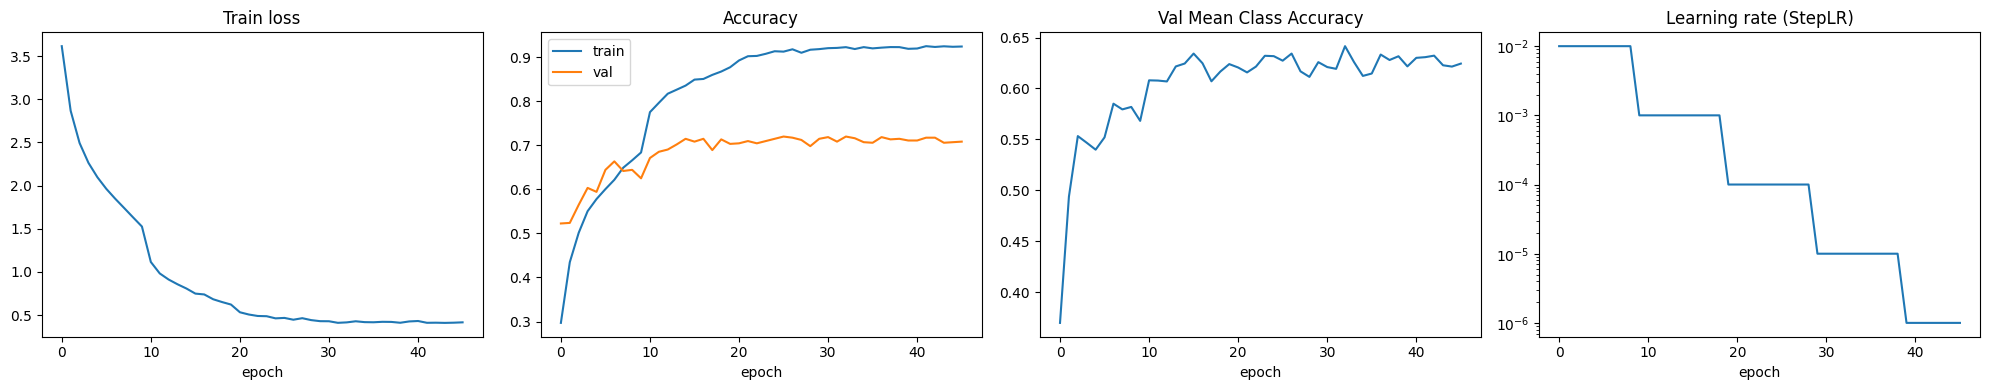

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(history["train_loss"]); axes[0].set_title("Train loss")
axes[1].plot(history["train_acc"], label="train"); axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(history["val_mca"]); axes[2].set_title("Val Mean Class Accuracy")
axes[3].plot(history["lr"]); axes[3].set_title("Learning rate (StepLR)"); axes[3].set_yscale("log")
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "training_curves.png"), dpi=200)
plt.show()


---

If `train_test_gap` here is meaningfully smaller than yesterday's ~30pp, that confirms the architecture/schedule mismatch (not head-dropout or NTU60 init) was the real driver. If the gap is still large, the remaining untested variable is `clip_len=100` vs our `30` - a bigger change, worth discussing before committing to redoing extraction for it.

In [11]:
import pandas as pd
log = pd.read_csv('/workspace/data/extraction_log.csv')
print(log['num_frames_total'].describe())
print()
print('percentiles:')
for p in [10, 25, 50, 75, 90, 95]:
    print(f'  {p}th: {log["num_frames_total"].quantile(p/100):.0f}')

count    7818.000000
mean       33.067920
std        12.479478
min         1.000000
25%        25.000000
50%        31.000000
75%        41.000000
max       104.000000
Name: num_frames_total, dtype: float64

percentiles:
  10th: 18
  25th: 25
  50th: 31
  75th: 41
  90th: 51
  95th: 56


In [12]:
print("clips with under 5 frames:", (log['num_frames_total'] < 5).sum())
print("clips with under 10 frames:", (log['num_frames_total'] < 10).sum())
log[log['num_frames_total'] < 5][['filepath', 'class_name', 'num_frames_total']]

clips with under 5 frames: 6
clips with under 10 frames: 36


,filepath,class_name,num_frames_total
1361,02_Lift/2022-08-31_19-09-07_dataset_set1_096_0...,02_Lift,1
1544,02_Lift/2022-09-06_17-42-57_dataset_set1_117_0...,02_Lift,3
2550,05_Drop Shot/2022-08-31_19-09-07_dataset_set1_...,05_Drop Shot,1
4170,09_Rush Shot/2022-09-06_19-07-23_dataset_set1_...,09_Rush Shot,2
6438,14_Smash/2022-08-30_18-10-55_dataset_set1_088_...,14_Smash,4
7597,16_Rear Court Flat Drive/2022-09-07_19-02-20_d...,16_Rear Court Flat Drive,4
